In [ ]:
!pip install matplotlib numpy scipy

In [2]:
%load_ext autoreload
%autoreload 2

from scipy.constants import speed_of_light as SPEED_OF_LIGHT
import numpy as np
import importlib
import matplotlib.pyplot as plt
import matplotlib as mpl
from copy import copy
import sys
import os
import pickle
from matplotlib.lines import Line2D

from simulation import *

# importlib.reload(simulation)

np.set_printoptions(threshold=sys.maxsize)

In [3]:
base_seed = 1234
batches = 10
realizations = 100

bs_setup = "mmWave"
scenarios = list(SCENARIOS[bs_setup].keys())

dl_prbs = SCENARIOS[bs_setup][scenarios[0]]["N_PRBS"] - SCENARIOS[bs_setup][scenarios[0]]["UPLINK_PRBS"]
sensing_portions = np.arange(0, dl_prbs+1)/dl_prbs
sensor_densities = SCENARIOS[bs_setup][scenarios[0]]["SENSOR_DENSITIES"]

In [4]:
metric_values = {
    metric: {
        (s,d): np.array([]).reshape(0, len(sensing_portions))
        for s in scenarios
        for d in sensor_densities
    }
    for metric in [
        "comm_ssr",
        "sensing_ssr",
        "ssr",
        "full_res_sens_portion"
    ]
}

for b in range(batches):
    np.random.seed(base_seed + b)

    for s in scenarios:
        data = copy(SCENARIOS[bs_setup][s])
        data["REALIZATIONS"] = realizations
        data = pos_vehicles(data, no_warning=True)
        for d in sensor_densities:
            data["SENSOR_DENSITY"] = d
            dl_prbs = data["N_PRBS"] - data["UPLINK_PRBS"]
            sensing_portions = np.arange(0, dl_prbs+1)/dl_prbs
            
            data = pos_sensors(data, no_warning=True)
            data = run_pre_allocation_and_assignment(data)
            data = run_angle_interference_derivations(data)
            data = alloc_beams(data)
            data = run_beam_allocation_interference_derivations(data)
            data = alloc_bandwidth(data, method="orthogonal_split_equal", sens_portions=sensing_portions)
            data = run_pre_assignment(data)
            data = assign_sensors(data)
            data = run_post_assignment(data)

            for metric in metric_values.keys():
                if metric == "max_sensor_demand":
                    values = data["sensor_demand"]
                    max_demand = np.max(values, axis=1) # [realization, alloc_decision]
                    mean_max_demand = np.mean(max_demand, axis=0) # [alloc_decision]
                    metric_values[metric][s,d] = np.vstack([metric_values[metric][s,d], mean_max_demand[np.newaxis, :]]) # [batch, alloc_decision]
                elif metric == "full_res_sens_portion":
                    values = data["unresolved_vehicles_rate"] # [realization, alloc_decision]
                    values = np.sum(values, axis = 0) # [alloc_decision]
                    metric_values[metric][s,d] = np.vstack([metric_values[metric][s,d], values[np.newaxis, :]]) # [batch, alloc_decision]
                    continue
                else:
                    values = data[metric]
                    mean_value = np.mean(values, axis=0) # [alloc_decision]
                    metric_values[metric][s,d] = np.vstack([metric_values[metric][s,d], mean_value[np.newaxis, :]]) # [batch, alloc_decision]


for s in scenarios:
    for d in sensor_densities:
        for metric in metric_values.keys():
            if metric == "full_res_sens_portion":
                sum_unresolved_vehicles = np.sum(metric_values[metric][s,d], axis=0)
                idxs = np.where(sum_unresolved_vehicles == 0)[0]# [alloc_decision]
                metric_values[metric][s,d] = idxs[0]
            else:
                metric_values[metric][s,d] = np.mean(metric_values[metric][s,d], axis=0) # [alloc_decision]

In [5]:
# Save metric_values
os.makedirs("results", exist_ok=True)
with open("results/3_slice_performance_metric_values.pkl", "wb") as f:
    pickle.dump(metric_values, f)

In [6]:
# Read metric_values
with open("results/3_slice_performance_metric_values.pkl", "rb") as f:
    metric_values = pickle.load(f)

In [7]:
scenario_labels = {
    (s, d): f"{SCENARIOS[bs_setup][s]['UE_DENSITY']*1e6:.0f}U {SCENARIOS[bs_setup][s]['TARGET_DENSITY']*1e6:.0f}T {d*1e6:.0f}S / km²"
    for s in scenarios
    for d in sensor_densities
}

scenario_labels_no_density = {
    s: f"{SCENARIOS[bs_setup][s]['UE_DENSITY']*1e6:.0f}U {SCENARIOS[bs_setup][s]['TARGET_DENSITY']*1e6:.0f}T / km²"
    for s in scenarios
}

best_sensing_portions = {
    (s,d): 0
    for s in scenarios
    for d in sensor_densities
}

for d in sensor_densities:
    for s in scenarios:
        print(f"Scenario: {scenario_labels[s,d]}")
        best_comm_ssr_idx = 0
        for metric in metric_values.keys():
            if metric == "full_res_sens_portion":
                continue
            best_sensing_portions[s,d] = np.argmax(metric_values[metric][s,d])
            if metric == "comm_ssr":
                best_comm_ssr_idx = best_sensing_portions[s,d]
            diff_to_best = metric_values[metric][s,d][best_sensing_portions[s,d]] - metric_values[metric][s,d]
            interval = 0.02 # 2% interval around best sensing portion
            diff_best_interval_idx = np.where(diff_to_best <= interval)
            range_around_best = (diff_best_interval_idx[0][0], diff_best_interval_idx[0][-1])            
            print(f"{metric} avg: {np.mean(metric_values[metric][s,d])*100:.2f}% - highest: {metric_values[metric][s,d][best_sensing_portions[s,d]]*100:.2f}% at sensing portion {sensing_portions[best_sensing_portions[s,d]]*100:.2f}%"+
                  f" - range of {interval*100:.0f}% around best: {sensing_portions[range_around_best[0]]*100:.0f}% to {sensing_portions[range_around_best[1]]*100:.0f}%"
            )
        print(f"sensing ssr at peak comm ssr {sensing_portions[best_comm_ssr_idx]*100:.2f}%: {metric_values['sensing_ssr'][s,d][best_comm_ssr_idx]*100:.2f}%")
        full_res_portion = metric_values["full_res_sens_portion"][s,d]
        full_res_portion_comm_ssr = metric_values['comm_ssr'][s,d][full_res_portion]
        full_res_portion_sensing_ssr = metric_values['sensing_ssr'][s,d][full_res_portion]
        full_res_portion_ssr = metric_values['ssr'][s,d][full_res_portion]
        print(f"Full res. at portion: {full_res_portion} -> {sensing_portions[full_res_portion]*100:.2f}%")
        print(f"At full res: comm_ssr: {full_res_portion_comm_ssr*100:.2f}%, sensing_ssr: {full_res_portion_sensing_ssr*100:.2f}%, ssr: {full_res_portion_ssr*100:.2f}%")
        print("")

Scenario: 50U 150T 5S / km²
comm_ssr avg: 79.35% - highest: 99.18% at sensing portion 4.88% - range of 2% around best: 5% to 37%
sensing_ssr avg: 57.03% - highest: 60.12% at sensing portion 100.00% - range of 2% around best: 17% to 100%
ssr avg: 68.19% - highest: 78.89% at sensing portion 26.83% - range of 2% around best: 10% to 54%
sensing ssr at peak comm ssr 4.88%: 46.75%
Full res. at portion: 2 -> 4.88%
At full res: comm_ssr: 99.18%, sensing_ssr: 46.75%, ssr: 72.96%

Scenario: 50U 300T 5S / km²
comm_ssr avg: 67.42% - highest: 96.74% at sensing portion 7.32% - range of 2% around best: 5% to 20%
sensing_ssr avg: 53.50% - highest: 56.85% at sensing portion 100.00% - range of 2% around best: 17% to 100%
ssr avg: 60.46% - highest: 75.22% at sensing portion 19.51% - range of 2% around best: 10% to 37%
sensing ssr at peak comm ssr 7.32%: 48.61%
Full res. at portion: 3 -> 7.32%
At full res: comm_ssr: 96.74%, sensing_ssr: 48.61%, ssr: 72.67%

Scenario: 150U 150T 5S / km²
comm_ssr avg: 31.63

In [8]:
for s in scenarios:
    for d in sensor_densities:
        print(f"Scenario: {scenario_labels[s,d]}")
        for metric in metric_values.keys():
            if metric == "max_sensor_demand":
                print(f"Max sensor demand: {np.max([metric_values[metric][s,d] for d in sensor_densities])/1e6:.2f} Mbps")
            else:
                print(f"Avg {metric}: {np.mean([metric_values[metric][s,d] for d in sensor_densities])*100:.2f}%")
        print("")

Scenario: 50U 150T 5S / km²
Avg comm_ssr: 79.41%
Avg sensing_ssr: 68.65%
Avg ssr: 74.03%
Avg full_res_sens_portion: 200.00%

Scenario: 50U 150T 15S / km²
Avg comm_ssr: 79.41%
Avg sensing_ssr: 68.65%
Avg ssr: 74.03%
Avg full_res_sens_portion: 200.00%

Scenario: 50U 300T 5S / km²
Avg comm_ssr: 67.45%
Avg sensing_ssr: 64.87%
Avg ssr: 66.16%
Avg full_res_sens_portion: 300.00%

Scenario: 50U 300T 15S / km²
Avg comm_ssr: 67.45%
Avg sensing_ssr: 64.87%
Avg ssr: 66.16%
Avg full_res_sens_portion: 300.00%

Scenario: 150U 150T 5S / km²
Avg comm_ssr: 31.62%
Avg sensing_ssr: 66.12%
Avg ssr: 48.87%
Avg full_res_sens_portion: 200.00%

Scenario: 150U 150T 15S / km²
Avg comm_ssr: 31.62%
Avg sensing_ssr: 66.12%
Avg ssr: 48.87%
Avg full_res_sens_portion: 200.00%

Scenario: 150U 300T 5S / km²
Avg comm_ssr: 18.40%
Avg sensing_ssr: 61.77%
Avg ssr: 40.09%
Avg full_res_sens_portion: 300.00%

Scenario: 150U 300T 15S / km²
Avg comm_ssr: 18.40%
Avg sensing_ssr: 61.77%
Avg ssr: 40.09%
Avg full_res_sens_portion: 3

In [9]:
print("Average performance across all scenarios:\n")

for d in sensor_densities:
    print(f"Sensor density: {d*1e6:.0f}S / km²")
    for metric in metric_values.keys():
        if metric == "full_res_sens_portion":
            continue
        avg_metric = np.mean([metric_values[metric][s,d] for s in scenarios])
        print(f"Avg {metric}: {avg_metric*100:.2f}%")
    print("")

print("Performance gain from first to last sensing density in each scenario:")

for s in scenarios:
    print(f"Scenario: {scenario_labels_no_density[s]}")
    for metric in metric_values.keys():
        if metric == "full_res_sens_portion":
            continue
        d1 = sensor_densities[0]
        d2 = sensor_densities[-1]
        avg_metric_d1 = np.mean(metric_values[metric][s,d1])
        avg_metric_d2 = np.mean(metric_values[metric][s,d2])
        gain = (avg_metric_d2 - avg_metric_d1)
        print(f"Avg absolute gain - {metric}: {gain*100:.2f}%")
    print("")

print("Performance gain from first to last sensing density averaged across all scenarios:")
for metric in metric_values.keys():
    if metric == "full_res_sens_portion":
        continue
    d1 = sensor_densities[0]
    d2 = sensor_densities[-1]
    avg_metric_d1 = np.mean([metric_values[metric][s,d1] for s in scenarios])
    avg_metric_d2 = np.mean([metric_values[metric][s,d2] for s in scenarios])
    gain = (avg_metric_d2 - avg_metric_d1)
    print(f"Avg absolute gain - {metric}: {gain*100:.2f}%")

Average performance across all scenarios:

Sensor density: 5S / km²
Avg comm_ssr: 49.19%
Avg sensing_ssr: 53.82%
Avg ssr: 51.51%

Sensor density: 15S / km²
Avg comm_ssr: 49.24%
Avg sensing_ssr: 76.88%
Avg ssr: 63.06%

Performance gain from first to last sensing density in each scenario:
Scenario: 50U 150T / km²
Avg absolute gain - comm_ssr: 0.11%
Avg absolute gain - sensing_ssr: 23.24%
Avg absolute gain - ssr: 11.68%

Scenario: 50U 300T / km²
Avg absolute gain - comm_ssr: 0.06%
Avg absolute gain - sensing_ssr: 22.73%
Avg absolute gain - ssr: 11.40%

Scenario: 150U 150T / km²
Avg absolute gain - comm_ssr: -0.01%
Avg absolute gain - sensing_ssr: 23.46%
Avg absolute gain - ssr: 11.72%

Scenario: 150U 300T / km²
Avg absolute gain - comm_ssr: 0.03%
Avg absolute gain - sensing_ssr: 22.83%
Avg absolute gain - ssr: 11.43%

Performance gain from first to last sensing density averaged across all scenarios:
Avg absolute gain - comm_ssr: 0.05%
Avg absolute gain - sensing_ssr: 23.06%
Avg absolute g

In [10]:
desired_sensing_portions = np.array([0.2, 0.4, 0.6, 0.8, 1.0])
for s in scenarios:
    for d in sensor_densities:
        print(f"Scenario: {scenario_labels[s,d]}")
        for metric in metric_values.keys():
            if metric == "full_res_sens_portion":
                continue
            for i in desired_sensing_portions:
                closest_idx = np.argmin(np.abs(sensing_portions - i))
                print(f"{metric} at sensing portion {sensing_portions[closest_idx]*100:.0f}%: {metric_values[metric][s,d][closest_idx]*100:.2f}")            
            print("")


Scenario: 50U 150T 5S / km²
comm_ssr at sensing portion 20%: 98.79
comm_ssr at sensing portion 39%: 97.02
comm_ssr at sensing portion 61%: 89.89
comm_ssr at sensing portion 80%: 68.48
comm_ssr at sensing portion 100%: 0.00

sensing_ssr at sensing portion 20%: 58.72
sensing_ssr at sensing portion 39%: 59.78
sensing_ssr at sensing portion 61%: 60.02
sensing_ssr at sensing portion 80%: 60.08
sensing_ssr at sensing portion 100%: 60.12

ssr at sensing portion 20%: 78.76
ssr at sensing portion 39%: 78.40
ssr at sensing portion 61%: 74.95
ssr at sensing portion 80%: 64.28
ssr at sensing portion 100%: 30.06

Scenario: 50U 150T 15S / km²
comm_ssr at sensing portion 20%: 98.95
comm_ssr at sensing portion 39%: 97.19
comm_ssr at sensing portion 61%: 90.18
comm_ssr at sensing portion 80%: 68.39
comm_ssr at sensing portion 100%: 0.00

sensing_ssr at sensing portion 20%: 82.67
sensing_ssr at sensing portion 39%: 83.74
sensing_ssr at sensing portion 61%: 83.97
sensing_ssr at sensing portion 80%: 84.02

In [11]:
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "font.size": 10,

    # IEEE-like sizing
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,

    # Better PDF output
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


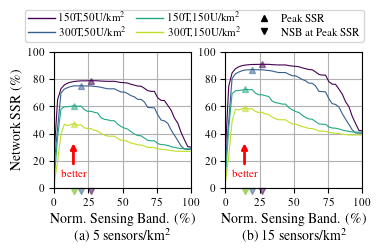

In [12]:
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "font.size": 10,

    # IEEE-like sizing
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,

    # Better PDF output
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# =========================================================
# Scenario labels
# =========================================================

scenario_dict = copy(SCENARIOS[bs_setup])

scenario_labels = {
    s: (f"{(SCENARIOS[bs_setup][s]['TARGET_DENSITY'])*1e6:.0f}T,"
        + f"{SCENARIOS[bs_setup][s]['UE_DENSITY']*1e6:.0f}U/km$^2$"
    )
    for s in scenarios
}
sensor_labels = [f"({chr(ord('a') + i)}) {sensor_densities[i]*1e6:.0f} sensors/km$^2$" for i in range(len(sensor_densities))]


# =========================================================
# Colors for scenarios
# =========================================================

colors = plt.cm.viridis(np.linspace(0, 0.9, len(scenarios)))

scenario_colors = {
    s: colors[i]
    for i, s in enumerate(scenarios)
}

# =========================================================
# Metrics per row
# =========================================================

metrics = ["ssr"]
row_titles = ["Network SSR"]

# =========================================================
# Figure setup (NOW 3x2)
# =========================================================

plt.rcParams.update({'font.size': 12})

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(sensor_densities),
    figsize=(3.5, 2),
    sharex=True,
    sharey=True
)

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.12,
    top=0.80,
    hspace=0.35,
    wspace=0.25
)

# =========================================================
# Plot
# =========================================================

for row, metric in enumerate(metrics):
    for col, sensor_density in enumerate(sensor_densities):

        ax = axes[col]

        for s in scenarios:
            
            y = np.array(metric_values[metric][s, sensor_density]) * 100
            x = sensing_portions * 100

            ax.plot(
                x,
                y,
                color=scenario_colors[s],
                linewidth=0.8,
            )

            # =========================================================
            # Peak marker (max y)
            # =========================================================
            max_idx = np.nanargmax(y)
            ax.plot(
                x[max_idx],
                y[max_idx],
                marker="^",
                color=scenario_colors[s],
                markersize=4,
                alpha=0.5,
                linestyle="None",
                clip_on=False
            )
            # Marker below x-axis to indicate sensing portion at peak
            ax.plot(
                x[max_idx],
                -2,
                marker="v",
                color=scenario_colors[s],
                markersize=4,
                alpha=0.5,
                linestyle="None",
                clip_on=False
            )

        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.tick_params(axis='y', labelleft=True)
        ax.grid()


        ax.annotate(
            "better",
            xy=(14, ax.get_ylim()[1] * 0.35),      # arrow tip (top)
            xytext=(14, ax.get_ylim()[1] * 0.1),  # text below
            arrowprops=dict(
                arrowstyle="->",
                lw=2,
                color="red",
            ),
            ha="center",
            va="center",
            fontsize=8,
            color="red"
        )

        if col == 0:
            ax.set_ylabel(f"{row_titles[row]} (\%)")

        if row == len(metrics) - 1:
            ax.set_xlabel("Norm. Sensing Band. (\%)\n"+sensor_labels[col])


# =========================================================
# Legend (scenarios)
# =========================================================

scenario_handles = [
    Line2D(
        [0], [0],
        color=scenario_colors[s],
        lw=1,
        label=scenario_labels[s]
    )
    for s in scenarios
]

# Peak marker legend entry
peak_handle = Line2D(
    [0], [0],
    marker="^",
    color="black",
    linestyle="None",
    markersize=4,
    label="Peak SSR"
)

xpeak_handle = Line2D(
    [0], [0],
    marker="v",
    color="black",
    linestyle="None",
    markersize=4,
    label="NSB at Peak SSR"
)

fig.legend(
    handles=scenario_handles + [peak_handle] + [xpeak_handle],
    loc="upper center",
    ncol=3,
    mode="expand",
    bbox_to_anchor=(0.00, 1.04, 1, 0),
    labelspacing=0.3,
    borderpad=0.3,
    handlelength=2.4,
    handletextpad=0.4,
)


# =========================================================
# Save
# =========================================================

os.makedirs("figures", exist_ok=True)

fig.savefig(
    "figures/3_slice_performance.pdf",
    bbox_inches="tight"
)

plt.show()